In [6]:
from pathlib import Path
import json

result_path = Path("../output_gpt-5-mini")

json_files = list(result_path.glob('**/RunnerResult_DefaultRefiner.json'))
data = []
for file in json_files:
    try:
        datapoint = json.load(open(file))
        data.append(datapoint)
    except Exception as e:
        print(file)
len(data)

59

In [7]:
success_ids = []

datapoint: dict
for datapoint in data:
    if "exploitSuccessResult" in datapoint:
        if datapoint["exploitSuccessResult"]:
            print(datapoint["advisory"]["id"])
            success_ids.append(datapoint["advisory"]["id"])
len(success_ids)

SNYK-JS-TREEKIT-1077068
SNYK-JS-OBJECTPATH-1569453
SNYK-JS-NPMUSERVALIDATE-1019352
SNYK-JS-HTMLPARSESTRINGIFY-1079306
npm:checkit:20180226
SNYK-JS-DECAL-1051028
SNYK-JS-NODEFORGE-598677
npm:ex-http-frame:20180226
npm:m-log:20160408
SNYK-JS-MATHJS-1016401
npm:modjs:20160407
SNYK-JS-KILLPORT-1078535
npm:node-staticserver:20180226
SNYK-JS-SERVEHEREJS-450884
SNYK-JS-KILLPROCESSBYNAME-1078534
SNYK-JS-MARKDOWNIT-2331914
SNYK-JS-UAPARSERJS-1072471
npm:run-this-place:20170508
npm:mobile-icon-resizer:20160408
SNYK-JS-DOTOBJECT-548905
SNYK-JS-POSTCSS-1255640
SNYK-JS-MOSC-571492
SNYK-JS-TRIMOFFNEWLINES-1296850
npm:zhaolei1111:20180315
SNYK-JS-ASSIGNDEEP-450211
SNYK-JS-COMPONENTFLATTEN-548907
npm:ptest:20180226
SNYK-JS-TOTALJS-1046672
SNYK-JS-MOOTOOLS-1325536


29

In [8]:
result_map = {
    "path-traversal": {"success": [], "failed": [], "error": []},
    "redos": {"success": [], "failed": [], "error": []},
    "command-injection": {"success": [], "failed": [], "error": []},
    "code-injection": {"success": [], "failed": [], "error": []},
    "prototype-pollution": {"success": [], "failed": [], "error": []},
}

datapoint: dict
for datapoint in data:
    try:
        llmIdentifiedVulnerabilityTypes = datapoint["llmIdentifiedVulnerabilityTypes"]
        # if len(llmIdentifiedVulnerabilityTypes) > 1:
        #     print(llmIdentifiedVulnerabilityTypes)
        #     break
        label = llmIdentifiedVulnerabilityTypes[0]["label"]
        id = datapoint["advisory"]["id"]
        if "exploitSuccessResult" in datapoint and datapoint["exploitSuccessResult"]:
            result_map[label]["success"].append(id)
        elif "error" in datapoint:
            result_map[label]["error"].append(id)
        else:
            result_map[label]["failed"].append(id)
    except:
        print(json.dumps(datapoint, indent=4))

In [9]:
# Convert each list in result_map to its length
for v_type, _data in result_map.items():
    for key in ["success", "failed", "error"]:
        _data[key] = len(list(set(_data[key])))

print("✅ Converted result_map (lists replaced with their lengths):")
result_map

✅ Converted result_map (lists replaced with their lengths):


{'path-traversal': {'success': 6, 'failed': 2, 'error': 7},
 'redos': {'success': 7, 'failed': 12, 'error': 2},
 'command-injection': {'success': 3, 'failed': 1, 'error': 0},
 'code-injection': {'success': 4, 'failed': 1, 'error': 0},
 'prototype-pollution': {'success': 9, 'failed': 5, 'error': 0}}

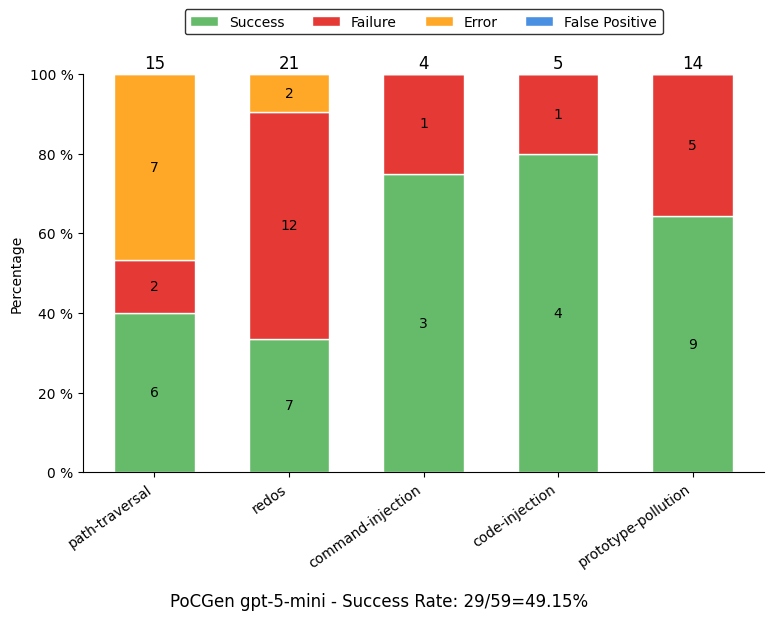

In [10]:
# Stacked percentage bar chart replicating the provided figure
import numpy as np
import matplotlib.pyplot as plt

# Data
categories = list(result_map.keys())
# Raw counts for each outcome per category
success = np.array([result["success"] for result in result_map.values()])
failure = np.array([result["failed"] for result in result_map.values()])
new = np.array([result["error"] for result in result_map.values()])
false_positive = np.array([0, 0, 0, 0, 0])

# Derived values
totals = success + failure + new + false_positive
success_pct = success / totals * 100.0
failure_pct = failure / totals * 100.0
new_pct = new / totals * 100.0
fp_pct = false_positive / totals * 100.0

x = np.arange(len(categories))
bar_width = 0.6

colors = {
    "Success": "#66bb6a",      # green
    "Failure": "#e53935",      # red
    "Error": "#ffa726",          # orange
    "False Positive": "#4a90e2",  # blue
}

fig, ax = plt.subplots(figsize=(8, 7))

# Stacked bars
bars_success = ax.bar(
    x, success_pct, bar_width, label="Success", color=colors["Success"], edgecolor="white"
)
bars_failure = ax.bar(
    x,
    failure_pct,
    bar_width,
    bottom=success_pct,
    label="Failure",
    color=colors["Failure"],
    edgecolor="white",
)
bars_new = ax.bar(
    x,
    new_pct,
    bar_width,
    bottom=success_pct + failure_pct,
    label="Error",
    color=colors["Error"],
    edgecolor="white",
)
bars_fp = ax.bar(
    x,
    fp_pct,
    bar_width,
    bottom=success_pct + failure_pct + new_pct,
    label="False Positive",
    color=colors["False Positive"],
    edgecolor="white",
)

# Helper to annotate count labels inside each segment (hide if segment is tiny)
def annotate_segment_counts(bars, counts, bottoms):
    for rect, count, bottom in zip(bars, counts, bottoms):
        height = rect.get_height()
        if height < 6:  # skip very small segments to avoid clutter
            continue
        ax.text(
            rect.get_x() + rect.get_width() / 2.0,
            bottom + height / 2.0,
            f"{int(count)}",
            ha="center",
            va="center",
            fontsize=10,
            color="black",
        )

annotate_segment_counts(bars_success, success, np.zeros_like(success_pct))
annotate_segment_counts(bars_failure, failure, success_pct)
annotate_segment_counts(bars_new, new, success_pct + failure_pct)
annotate_segment_counts(bars_fp, false_positive, success_pct + failure_pct + new_pct)

# Totals above bars
ax.set_ylim(0, 100)
for xi, total in zip(x, totals):
    ax.text(xi, 100.5, f"{int(total)}", ha="center", va="bottom", fontsize=12, clip_on=False)

# Axes formatting
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=35, ha="right")
ax.set_ylabel("Percentage")
ax.set_yticks(np.arange(0, 101, 20))
ax.set_yticklabels([f"{v} %" for v in np.arange(0, 101, 20)])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend on top
legend = ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.18),
    ncol=4,
    frameon=True,
)
legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("black")

# Caption below the chart
plt.figtext(
    0.5,
    0.01,
    f"{result_path.name.replace('_', ' ').replace('output', 'PoCGen')} - Success Rate: {len(success_ids)}/{len(data)}={round(len(success_ids)/len(data)*100, 2)}%",
    ha="center",
    fontsize=12,
)

plt.tight_layout(rect=[0.02, 0.04, 1, 0.92])
plt.show()
